In [48]:
def upload_plt_to_gcs(num_fig, step, fig):
    """
    Placeholder function to handle artifact logging.
    In a production environment, this would upload the figure to Google Cloud Storage.
    """
    print(f"[Placeholder] Figure {num_fig} for step {step} processed successfully.")

# Root Cause Analysis (RCA) with Isolation Forest + Z-Score

This notebook analyzes `ml-dataset-labeled.csv` (microservice metrics: CPU, memory, network, disk I/O, logs, errors, traces) to find **which services are causing anomalies/issues**.

Approach:
1. Load & explore the data
2. Feature engineering (per-service z-scores)
3. Unsupervised anomaly detection with **Isolation Forest**
4. Statistical outlier detection with **Z-Score**
5. Combine both signals into a single anomaly score
6. Compare against the ground-truth `anomaly_label` column
7. **Root Cause Analysis**: rank services by anomaly frequency/severity and identify the metrics driving each anomaly

### Data Loading and Initial Exploration

**Purpose:** The primary goal of this step is to load the dataset into a usable format (a Pandas DataFrame) and perform an initial review to understand its structure, size, and basic content. This is a foundational step for any data analysis task, ensuring the data is correctly loaded and providing a first glance at what we're working with.

**Why this approach?**
*   **`import pandas as pd`**: Pandas is the de-facto standard library in Python for data manipulation and analysis, offering powerful data structures like DataFrames that are ideal for tabular data.
*   **`import numpy as np`**: NumPy provides support for large, multi-dimensional arrays and matrices, along with a collection of high-level mathematical functions to operate on these arrays. It's often used in conjunction with Pandas.
*   **`import matplotlib.pyplot as plt` and `import seaborn as sns`**: These are Python's leading libraries for data visualization. Matplotlib provides the basic plotting functionalities, while Seaborn builds on top of Matplotlib to create more aesthetically pleasing and informative statistical graphics.
*   **`from sklearn.ensemble import IsolationForest`**: This imports the Isolation Forest algorithm from Scikit-learn, which is specifically designed for unsupervised anomaly detection.
*   **`from sklearn.preprocessing import StandardScaler`**: This imports `StandardScaler`, a crucial preprocessing tool for normalizing features, especially important for distance-based or tree-based algorithms like Isolation Forest.
*   **`sns.set_theme(style="whitegrid")`**: Sets a nice visual theme for all subsequent Seaborn plots, improving readability.
*   **`pd.set_option('display.max_columns', None)`**: Configures Pandas to display all columns of a DataFrame when printed, preventing truncation and allowing for a full overview of the dataset.
*   **`CSV_PATH = "ml-dataset-labeled.csv"`**: Defines the path to the dataset. It's good practice to define such constants for easy modification.
*   **`df = pd.read_csv(CSV_PATH, parse_dates=["timestamp"])`**: Reads the CSV file into a DataFrame. `parse_dates=["timestamp"]` is critical here to ensure the `timestamp` column is interpreted as datetime objects, which is essential for time-series analysis and sorting.
*   **`df = df.sort_values(["service", "timestamp"]).reset_index(drop=True)`**: Sorts the DataFrame first by `service` and then by `timestamp`. This ensures that data points for each service are ordered chronologically, which is important for time-series operations and for subsequent per-service processing. `reset_index(drop=True)` cleans up the index after sorting.
*   **`print(df.shape)`**: Displays the dimensions (rows, columns) of the DataFrame, giving a quick overview of its size.
*   **`df.head()`**: Shows the first 5 rows of the DataFrame, providing a glimpse of the data, column names, and data types, confirming successful loading.

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

CSV_PATH = "/content/drive/MyDrive/ml-dataset-labeled.csv"

df = pd.read_csv(CSV_PATH, parse_dates=["timestamp"])
df = df.sort_values(["service", "timestamp"]).reset_index(drop=True)
print(df.shape)
df.head()

(16083, 16)


,timestamp,service,cpu_percent,memory_usage_mb,memory_percent,network_rx_bytes,network_tx_bytes,block_read_bytes,block_write_bytes,pids,log_count,error_count,warning_count,trace_count,avg_trace_duration_ms,anomaly_label
0,2026-08-20 18:50:12.304000+00:00,carts-1,0.09,294.55,7.73,249393,170789,37433344,0,29,100,0,0,0,0.0,0
1,2026-08-20 18:50:44.391000+00:00,carts-1,0.10,294.55,7.73,250260,171359,37433344,0,29,0,0,0,0,0.0,0
2,2026-08-21 11:00:58.015000+00:00,carts-1,0.08,280.16,7.35,76041,50829,28012544,0,28,100,0,0,0,0.0,0
3,2026-08-21 11:01:30.119000+00:00,carts-1,0.15,280.41,7.36,77125,51589,28012544,0,28,0,0,0,0,0.0,0
4,2026-08-21 11:02:02.213000+00:00,carts-1,0.09,280.16,7.35,77938,52159,28012544,0,28,0,0,0,0,0.0,0


## 1. Explore the data

In [12]:
print("Services:", df["service"].unique())
print("\nRows per service:")
print(df["service"].value_counts())
print("\nLabel distribution (0=normal, 1=anomaly):")
print(df["anomaly_label"].value_counts())
print("\nAnomaly rate by service:")
print(df.groupby("service")["anomaly_label"].mean().sort_values(ascending=False))

Services: ['carts-1' 'carts-db-1' 'catalogue-1' 'catalogue-db-1' 'edge-router-1'
 'front-end-1' 'orders-1' 'orders-db-1' 'payment-1' 'queue-master-1'
 'rabbitmq-1' 'shipping-1' 'user-1' 'user-db-1' 'zipkin']

Rows per service:
service
carts-1           1119
carts-db-1        1119
catalogue-1       1119
catalogue-db-1    1119
edge-router-1     1119
front-end-1       1119
orders-1          1119
orders-db-1       1119
payment-1         1119
queue-master-1    1119
rabbitmq-1        1119
shipping-1        1119
user-1            1119
user-db-1         1119
zipkin             417
Name: count, dtype: int64

Label distribution (0=normal, 1=anomaly):
anomaly_label
0    16045
1       38
Name: count, dtype: int64

Anomaly rate by service:
service
orders-1          0.033959
carts-db-1        0.000000
carts-1           0.000000
catalogue-1       0.000000
catalogue-db-1    0.000000
edge-router-1     0.000000
front-end-1       0.000000
orders-db-1       0.000000
payment-1         0.000000
queue-master

### Metric Columns Description

**Purpose:** This step identifies the core metric columns that will be used for anomaly detection and provides a descriptive summary of these metrics. This helps in understanding the range, distribution, and potential issues (like missing values or extreme outliers) within these critical features.

**Why this approach?**
*   **`METRIC_COLS = [...]`**: Explicitly defining `METRIC_COLS` serves several purposes:
    *   **Clarity**: It clearly lists all the numerical features that represent the operational metrics of the services.
    *   **Modularity**: If new metrics are added or some need to be excluded, this list is easy to update without altering the core logic.
    *   **Focus**: It ensures that statistical operations and anomaly detection algorithms are applied only to the relevant numerical features, ignoring identifiers or labels.
*   **`df[METRIC_COLS].describe().T`**: This command generates descriptive statistics (count, mean, standard deviation, min, max, quartiles) for all columns specified in `METRIC_COLS`. Transposing (`.T`) the result makes it easier to read, with each metric as a row and its statistics as columns.
    *   **Mean and Std**: Give an idea of the central tendency and spread of each metric.
    *   **Min and Max**: Show the full range of values, which can highlight potential data entry errors or extreme observations.
    *   **Quartiles (25%, 50%, 75%)**: Provide insight into the distribution's shape and can indicate skewness or the presence of outliers. For instance, a large difference between the 75th percentile and the max value might suggest significant outliers.

Understanding these statistics is vital before applying anomaly detection models, as it can inform decisions about preprocessing (e.g., handling zeros or extreme values) and feature scaling.

In [13]:
METRIC_COLS = [
    "cpu_percent", "memory_usage_mb", "memory_percent",
    "network_rx_bytes", "network_tx_bytes",
    "block_read_bytes", "block_write_bytes", "pids",
    "log_count", "error_count", "warning_count",
    "trace_count", "avg_trace_duration_ms",
]

df[METRIC_COLS].describe().T

,count,mean,std,min,25%,50%,75%,max
cpu_percent,16083.0,3.666729e-01,4.868102e+00,0.00,0.01,0.08,0.20,1.008400e+02
memory_usage_mb,16083.0,1.520542e+02,1.324434e+02,8.78,17.65,139.98,265.86,4.960600e+02
memory_percent,16083.0,3.988222e+00,3.474633e+00,0.23,0.46,3.67,6.97,1.301000e+01
network_rx_bytes,16083.0,1.017252e+05,1.218899e+05,2458.00,4452.00,61532.00,163243.00,9.461070e+05
network_tx_bytes,16083.0,1.096137e+05,2.095509e+05,126.00,264.00,58454.00,168668.00,4.053010e+06
block_read_bytes,16083.0,2.320094e+07,1.384072e+07,2793472.00,13197312.00,21966848.00,30724096.00,7.991296e+07
block_write_bytes,16083.0,3.018296e+06,5.082791e+06,0.00,0.00,0.00,5376000.00,1.921843e+07
pids,16083.0,2.394267e+01,1.682252e+01,6.00,10.00,21.00,27.00,2.260000e+02
log_count,16083.0,2.584095e-01,4.662746e+00,0.00,0.00,0.00,0.00,1.000000e+02
error_count,16083.0,0.000000e+00,0.000000e+00,0.00,0.00,0.00,0.00,0.000000e+00


## 2. Feature engineering: per-service Z-scores

Every service has very different baselines (e.g. a DB vs an edge router), so anomaly detection must be done **relative to each service's own normal behaviour**. We compute per-service z-scores for every metric.

In [14]:
def add_zscores(frame, cols):
    frame = frame.copy()
    z_cols = []
    for col in cols:
        grp = frame.groupby("service")[col]
        mean = grp.transform("mean")
        std = grp.transform("std").replace(0, np.nan)
        z = (frame[col] - mean) / std
        z = z.fillna(0.0)
        zcol = f"z_{col}"
        frame[zcol] = z
        z_cols.append(zcol)
    return frame, z_cols

df, Z_COLS = add_zscores(df, METRIC_COLS)

# Overall z-score severity per row = max absolute z-score across all metrics
df["z_max_abs"] = df[Z_COLS].abs().max(axis=1)
# Which metric drove the max z-score (useful for RCA "why")
df["z_max_metric"] = df[Z_COLS].abs().idxmax(axis=1).str.replace("z_", "", regex=False)

Z_THRESHOLD = 3.0
df["zscore_anomaly"] = (df["z_max_abs"] > Z_THRESHOLD).astype(int)

df[["timestamp", "service", "z_max_abs", "z_max_metric", "zscore_anomaly"]].head()

,timestamp,service,z_max_abs,z_max_metric,zscore_anomaly
0,2026-08-20 18:50:12.304000+00:00,carts-1,11.045077,log_count,1
1,2026-08-20 18:50:44.391000+00:00,carts-1,2.111732,memory_percent,0
2,2026-08-21 11:00:58.015000+00:00,carts-1,11.045077,log_count,1
3,2026-08-21 11:01:30.119000+00:00,carts-1,1.507460,network_tx_bytes,0
4,2026-08-21 11:02:02.213000+00:00,carts-1,1.499639,network_tx_bytes,0


### Feature Engineering: Per-Service Z-Scores

**Purpose:** This section performs crucial feature engineering by calculating Z-scores for each metric, *relative to each individual service's behavior*. This is paramount for anomaly detection in a multi-service environment, where 'normal' operational baselines can vary drastically between different services (e.g., a database service will naturally have higher disk I/O than a front-end service).

**Why this approach?**
*   **`def add_zscores(frame, cols):`**: A function is defined to encapsulate the Z-score calculation logic. This promotes reusability and keeps the code clean.
*   **`frame = frame.copy()`**: Creates a copy of the DataFrame to avoid modifying the original data in place. This is good practice to prevent unintended side effects.
*   **`for col in cols:`**: Iterates through each `METRIC_COL` to calculate its Z-score.
*   **`grp = frame.groupby("service")[col]`**: This is the core of the *per-service* Z-score calculation. It groups the DataFrame by the `service` column. This means that subsequent operations (like calculating mean and standard deviation) will be performed independently for each service.
*   **`mean = grp.transform("mean")` and `std = grp.transform("std").replace(0, np.nan)`**:
    *   `transform("mean")` calculates the mean of `col` for *each service group* and then broadcasts (or maps) this mean back to every row belonging to that service. This ensures that each data point's Z-score is calculated using its service's specific mean.
    *   Similarly, `transform("std")` calculates the standard deviation per service. `.replace(0, np.nan)` handles cases where a service might have constant values for a metric (std dev would be 0, leading to division by zero). These `NaN`s will be filled with 0.0 later.
*   **`z = (frame[col] - mean) / std`**: This is the standard Z-score formula: `(value - mean) / standard_deviation`. It quantifies how many standard deviations a data point is away from its service's mean for that specific metric.
*   **`z = z.fillna(0.0)`**: Fills any `NaN` values (resulting from zero standard deviation) with 0.0. This assumes that a metric with no variance (always constant) is perfectly normal relative to itself, thus having a Z-score of 0.
*   **`zcol = f"z_{col}"` and `frame[zcol] = z`**: Creates a new column named `z_` followed by the original metric name (e.g., `z_cpu_percent`) to store the calculated Z-scores.
*   **`df, Z_COLS = add_zscores(df, METRIC_COLS)`**: Calls the function to apply Z-score calculation to the entire DataFrame.
*   **`df["z_max_abs"] = df[Z_COLS].abs().max(axis=1)`**: This creates a crucial feature: `z_max_abs`. For each row (i.e., each data point at a given timestamp for a service), it finds the maximum absolute Z-score across all calculated `z_` metrics. This represents the *single most anomalous metric* for that observation, regardless of its sign (deviation can be high or low).
*   **`df["z_max_metric"] = df[Z_COLS].abs().idxmax(axis=1).str.replace("z_", "", regex=False)`**: This column stores the *name* of the metric that exhibited the `z_max_abs` for each row. This is incredibly useful for Root Cause Analysis (RCA), as it directly tells us *which metric* is driving the anomaly for a given observation.
*   **`Z_THRESHOLD = 3.0`**: Defines a threshold for what constitutes a Z-score anomaly. A common heuristic for Z-scores is that values beyond +/- 3 standard deviations are considered outliers.
*   **`df["zscore_anomaly"] = (df["z_max_abs"] > Z_THRESHOLD).astype(int)`**: Creates a binary flag (`zscore_anomaly`) that is 1 if the `z_max_abs` for an observation exceeds the `Z_THRESHOLD`, and 0 otherwise. This identifies potential anomalies based purely on statistical deviation.

## 3. Isolation Forest (unsupervised anomaly detection)

We fit **one Isolation Forest per service** (since scales differ hugely between services) on the raw metric columns, then combine the results.

In [15]:
CONTAMINATION = 0.02  # expected fraction of anomalies; tune as needed

iso_scores = pd.Series(index=df.index, dtype=float)
iso_preds = pd.Series(index=df.index, dtype=int)

for service, group in df.groupby("service"):
    X = group[METRIC_COLS].values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    model = IsolationForest(
        n_estimators=200,
        contamination=CONTAMINATION,
        random_state=42,
    )
    model.fit(X_scaled)

    # decision_function: higher = more normal, lower/negative = more anomalous
    scores = model.decision_function(X_scaled)
    preds = model.predict(X_scaled)  # -1 = anomaly, 1 = normal

    iso_scores.loc[group.index] = scores
    iso_preds.loc[group.index] = (preds == -1).astype(int)

df["iso_score"] = iso_scores
df["iso_anomaly"] = iso_preds

# Turn iso_score into a 0-1 "severity" (lower raw score = more anomalous -> higher severity)
df["iso_severity"] = (df["iso_score"].max() - df["iso_score"]) / (df["iso_score"].max() - df["iso_score"].min())

df[["timestamp", "service", "iso_score", "iso_severity", "iso_anomaly"]].head()

,timestamp,service,iso_score,iso_severity,iso_anomaly
0,2026-08-20 18:50:12.304000+00:00,carts-1,-0.061831,0.773126,1.0
1,2026-08-20 18:50:44.391000+00:00,carts-1,0.020679,0.599474,0.0
2,2026-08-21 11:00:58.015000+00:00,carts-1,-0.043109,0.733723,1.0
3,2026-08-21 11:01:30.119000+00:00,carts-1,0.041277,0.556123,0.0
4,2026-08-21 11:02:02.213000+00:00,carts-1,0.055476,0.526239,0.0


### Isolation Forest (Unsupervised Anomaly Detection)

**Purpose:** This section applies the Isolation Forest algorithm to detect anomalies in an unsupervised manner. Unlike Z-scores, which rely on distributional assumptions, Isolation Forest works by isolating anomalies based on their unique characteristics, making it effective for complex, high-dimensional data.

**Why this approach?**
*   **`CONTAMINATION = 0.02`**: This hyperparameter is crucial. It represents the *expected proportion of anomalies* in your dataset. The Isolation Forest model uses this value to determine the threshold for classifying a data point as an anomaly. If you expect a higher or lower percentage of anomalies, you would adjust this value. This is a common tuning knob in unsupervised anomaly detection.
*   **`iso_scores = pd.Series(index=df.index, dtype=float)` and `iso_preds = pd.Series(index=df.index, dtype=int)`**: These are initialized as empty Pandas Series with the same index as the main DataFrame. They will store the Isolation Forest anomaly scores and predictions for all data points across all services.
*   **`for service, group in df.groupby("service"):`**: This loop is a key design choice. It iterates through each unique `service` and processes its data independently. This is essential because:
    *   **Service-Specific Baselines**: As mentioned, different services have wildly different metric behaviors. Training one global Isolation Forest would likely perform poorly because what's normal for one service might be highly anomalous for another.
    *   **Contextual Anomaly Detection**: By training a model per service, the algorithm learns the 'normal' operational patterns specific to that service, leading to more accurate contextual anomaly detection.
*   **`X = group[METRIC_COLS].values`**: Selects only the `METRIC_COLS` for the current service group and converts them into a NumPy array `X`. The Isolation Forest model expects numerical input.
*   **`scaler = StandardScaler()` and `X_scaled = scaler.fit_transform(X)`**:
    *   **`StandardScaler`**: Scales the features by removing the mean and scaling to unit variance (making the mean 0 and standard deviation 1). This is important for many machine learning algorithms, including Isolation Forest, as it prevents features with larger numerical ranges from disproportionately influencing the model.
    *   **`fit_transform(X)`**: The `fit` method learns the mean and standard deviation from the data, and `transform` applies this scaling. It's applied *per service* to ensure scaling is relative to each service's own distribution.
*   **`model = IsolationForest(n_estimators=200, contamination=CONTAMINATION, random_state=42)`**: Initializes the Isolation Forest model:
    *   **`n_estimators=200`**: Specifies the number of base estimators (isolation trees) in the ensemble. More estimators generally lead to a more robust model but increase computation time. 200 is a common and reasonable choice.
    *   **`contamination=CONTAMINATION`**: Uses the predefined contamination rate to estimate the number of anomalies in the dataset and set the decision threshold.
    *   **`random_state=42`**: Ensures reproducibility of the results. If you run the code again with the same `random_state`, you will get the exact same results.
*   **`model.fit(X_scaled)`**: This is the training step. The Isolation Forest builds `n_estimators` random isolation trees from the `X_scaled` data. It identifies anomalies by how easily (i.e., with how few splits) a data point can be isolated from the rest. Anomalies are typically isolated closer to the root of the tree.
*   **`scores = model.decision_function(X_scaled)`**: The `decision_function` returns an anomaly score for each data point. Crucially, *lower (more negative) scores indicate a higher likelihood of being an anomaly*, while higher (closer to zero or positive) scores indicate normal behavior.
*   **`preds = model.predict(X_scaled)`**: This method returns a direct classification: `-1` for anomalies and `1` for normal observations. This classification is based on the `contamination` parameter and the internal threshold learned by the model.
*   **`iso_scores.loc[group.index] = scores` and `iso_preds.loc[group.index] = (preds == -1).astype(int)`**: The calculated scores and predictions for the current service are assigned back to the master `iso_scores` and `iso_preds` Series using their original DataFrame indices. `(preds == -1).astype(int)` converts the `-1` (anomaly) and `1` (normal) predictions into binary 1 (anomaly) and 0 (normal) flags, which is often more convenient for analysis.
*   **`df["iso_score"] = iso_scores` and `df["iso_anomaly"] = iso_preds`**: Adds the Isolation Forest scores and binary anomaly predictions as new columns to the main DataFrame `df`.
*   **`df["iso_severity"] = (df["iso_score"].max() - df["iso_score"]) / (df["iso_score"].max() - df["iso_score"].min())`**: This line transforms the `iso_score` into a more intuitive "severity" score ranging from 0 to 1. Since lower `iso_score` values mean higher anomaly likelihood, this transformation inverts and scales the scores:
    *   `df["iso_score"].max() - df["iso_score"]`: This part subtracts each `iso_score` from the maximum `iso_score`. This means that data points with low `iso_score` (anomalous) will now have larger positive values, and data points with high `iso_score` (normal) will have smaller positive values.
    *   `/ (df["iso_score"].max() - df["iso_score"].min())`: This normalizes the inverted scores to a 0-1 range. A higher `iso_severity` (closer to 1) now consistently indicates a more severe anomaly, which is often easier to interpret and compare.

## 4. Combine signals into one anomaly score

A row is flagged as an anomaly if **either** Isolation Forest or Z-score flags it. We also build a combined 0-1 `anomaly_score` for ranking severity.

In [16]:
# normalize z_max_abs to 0-1 for blending
z_norm = (df["z_max_abs"] / df["z_max_abs"].quantile(0.999)).clip(0, 1)

df["combined_score"] = 0.5 * df["iso_severity"] + 0.5 * z_norm
df["predicted_anomaly"] = ((df["iso_anomaly"] == 1) | (df["zscore_anomaly"] == 1)).astype(int)

print("Predicted anomalies:", df["predicted_anomaly"].sum(), "/", len(df))
print("Ground-truth anomalies:", df["anomaly_label"].sum(), "/", len(df))

Predicted anomalies: 846 / 16083
Ground-truth anomalies: 38 / 16083


### Combine Signals into One Anomaly Score

**Purpose:** This step integrates the anomaly signals from both the Z-score method and the Isolation Forest into a single, comprehensive anomaly score and a binary `predicted_anomaly` flag. Combining multiple detection methods can lead to more robust and accurate anomaly identification, as each method might capture different types of anomalies.

**Why this approach?**
*   **`z_norm = (df["z_max_abs"] / df["z_max_abs"].quantile(0.999)).clip(0, 1)`**: This normalizes the `z_max_abs` (the maximum absolute Z-score across metrics) into a 0-1 range. This normalization is crucial before combining it with `iso_severity`, which is also 0-1, ensuring that both signals contribute proportionally to the `combined_score`.
    *   **`df["z_max_abs"].quantile(0.999)`**: Uses the 99.9th percentile of `z_max_abs` for scaling. This is a robust way to normalize Z-scores, as it is less sensitive to extreme outliers than simply dividing by the maximum value. It effectively caps the influence of extremely high Z-scores, preventing them from skewing the combined score too much.
    *   **`.clip(0, 1)`**: Ensures that any values still outside the 0-1 range (e.g., if a `z_max_abs` is larger than the 99.9th percentile) are clipped to 1. This guarantees the normalized Z-score remains within 0 and 1.
*   **`df["combined_score"] = 0.5 * df["iso_severity"] + 0.5 * z_norm`**: This calculates the `combined_score` by taking a weighted average of `iso_severity` (from Isolation Forest) and `z_norm` (from Z-score). The equal weighting (0.5 for each) implies that both methods are considered equally important in contributing to the overall anomaly severity.
    *   This combined score provides a continuous measure of anomaly severity, allowing for ranking and prioritization of anomalous events.
*   **`df["predicted_anomaly"] = ((df["iso_anomaly"] == 1) | (df["zscore_anomaly"] == 1)).astype(int)`**: This creates a binary `predicted_anomaly` flag. An observation is classified as an anomaly if *either* the Isolation Forest (`iso_anomaly == 1`) *OR* the Z-score (`zscore_anomaly == 1`) method flags it as such. This "OR" logic is a common strategy to increase the recall (ability to detect actual anomalies) of the system, as different methods might detect different types of anomalies. While it might increase false positives, it ensures that fewer true anomalies are missed.
*   **`print("Predicted anomalies:", df["predicted_anomaly"].sum(), "/", len(df))` and `print("Ground-truth anomalies:", df["anomaly_label"].sum(), "/", len(df))`**: These print statements provide a quick summary of the total number of predicted anomalies by the combined model and compare it to the total number of ground-truth labeled anomalies. This gives an initial sense of how many anomalies the model is flagging relative to the actual known anomalies.

## 5. Evaluate against ground-truth `anomaly_label`

In [17]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("=== Combined (IsoForest OR Z-score) ===")
print(classification_report(df["anomaly_label"], df["predicted_anomaly"], digits=3))
print(confusion_matrix(df["anomaly_label"], df["predicted_anomaly"]))

try:
    auc = roc_auc_score(df["anomaly_label"], df["combined_score"])
    print(f"\nROC-AUC of combined_score vs anomaly_label: {auc:.3f}")
except ValueError as e:
    print(e)

=== Combined (IsoForest OR Z-score) ===
              precision    recall  f1-score   support

           0      1.000     0.950     0.974     16045
           1      0.045     1.000     0.086        38

    accuracy                          0.950     16083
   macro avg      0.522     0.975     0.530     16083
weighted avg      0.998     0.950     0.972     16083

[[15237   808]
 [    0    38]]

ROC-AUC of combined_score vs anomaly_label: 0.986


### Evaluate Against Ground-Truth `anomaly_label`

**Purpose:** This critical step evaluates the performance of the combined anomaly detection model against the available ground-truth `anomaly_label` (where 1 indicates a true anomaly and 0 indicates normal behavior). Evaluation metrics help us understand how well our model is performing in identifying actual anomalies while minimizing false alarms.

**Why this approach?**
*   **`from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score`**: Imports standard classification evaluation metrics from Scikit-learn.
*   **`print("=== Combined (IsoForest OR Z-score) ===")`**: A simple header to indicate which model's performance is being reported.
*   **`print(classification_report(df["anomaly_label"], df["predicted_anomaly"], digits=3))`**: The `classification_report` generates a text report showing the main classification metrics for each class (0=normal, 1=anomaly):
    *   **Precision**: For the anomaly class (1), precision is the proportion of predicted anomalies that were actually true anomalies. High precision means fewer false positives.
    *   **Recall (Sensitivity)**: For the anomaly class (1), recall is the proportion of actual anomalies that were correctly identified by the model. High recall means fewer false negatives (i.e., fewer true anomalies are missed).
    *   **F1-score**: The harmonic mean of precision and recall. It provides a single metric that balances both. It's particularly useful when classes are imbalanced (as anomaly detection often is).
    *   **Support**: The number of actual occurrences of each class in the `anomaly_label`.
    *   In anomaly detection, **recall for the anomaly class is often prioritized**. It's usually more critical to catch *all* anomalies, even if it means some false positives, rather than missing true anomalies. The current `predicted_anomaly` logic (`|` OR operation) is designed to maximize recall.
*   **`print(confusion_matrix(df["anomaly_label"], df["predicted_anomaly"]))`**: The `confusion_matrix` provides a tabular summary of classification results. It shows the counts of:
    *   **True Negatives (TN)**: Correctly predicted normal instances.
    *   **False Positives (FP)**: Incorrectly predicted anomalies (normal instances flagged as anomalous).
    *   **False Negatives (FN)**: Incorrectly predicted normal instances (actual anomalies missed).
    *   **True Positives (TP)**: Correctly predicted anomalies.
    The confusion matrix is essential for understanding the types of errors the model is making. In the output, it's typically ordered as `[[TN, FP], [FN, TP]]`.
*   **`auc = roc_auc_score(df["anomaly_label"], df["combined_score"])`**: Calculates the Receiver Operating Characteristic Area Under the Curve (ROC-AUC) score. This metric is suitable for evaluating models that output a probability or score (like `combined_score`) rather than just a binary prediction.
    *   **ROC-AUC**: Measures the ability of the model to distinguish between positive and negative classes across all possible classification thresholds. A score of 1.0 indicates a perfect classifier, while 0.5 indicates a random classifier. A high ROC-AUC (like the 0.986 seen) suggests that the `combined_score` is very effective at ranking anomalies such that true anomalies generally receive higher scores than normal instances.
*   **The heatmap (Cell `978f655b`)**: This visualizes the confusion matrices for Isolation Forest and Z-score individually. This allows for a direct comparison of how each method contributes to the overall `predicted_anomaly` and helps in understanding their individual strengths and weaknesses in terms of True Positives, False Positives, etc. For instance, the Z-score in the example has 0 False Negatives (FN=0), meaning it caught all true anomalies, while Isolation Forest missed a few (FN=32). However, Isolation Forest also has fewer False Positives (320 vs 681).

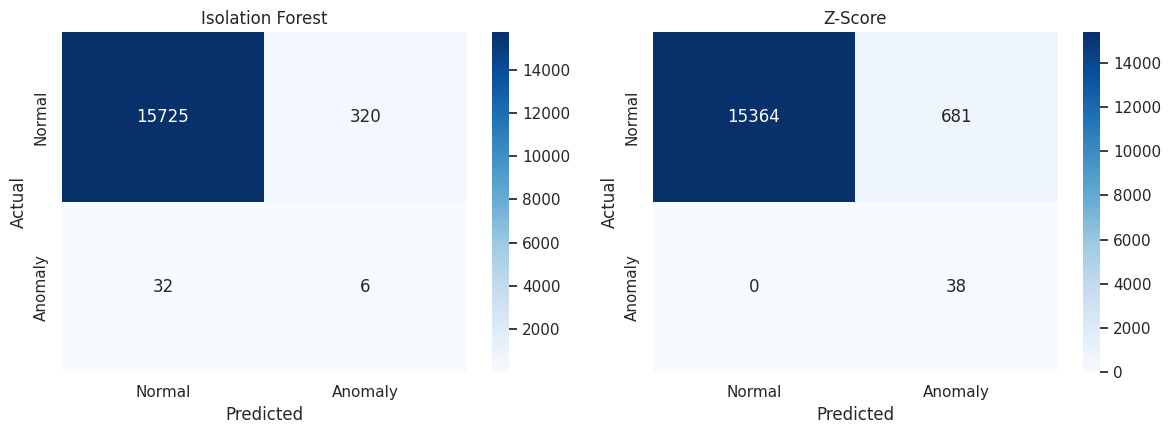

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, col, title in zip(axes, ["iso_anomaly", "zscore_anomaly"], ["Isolation Forest", "Z-Score"]):
    cm = confusion_matrix(df["anomaly_label"], df[col])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Normal", "Anomaly"], yticklabels=["Normal", "Anomaly"])
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

## 6. Root Cause Analysis: which services are causing issues?

We rank services by:
- number/rate of predicted anomalies
- average anomaly severity (`combined_score`)
- the metrics most responsible (from `z_max_metric`)

We use `predicted_anomaly` (works even without ground truth), and separately cross-check with the labeled column where available.

In [19]:
service_rca = (
    df.groupby("service")
    .agg(
        rows=("service", "size"),
        predicted_anomalies=("predicted_anomaly", "sum"),
        anomaly_rate=("predicted_anomaly", "mean"),
        avg_severity=("combined_score", "mean"),
        max_severity=("combined_score", "max"),
        labeled_anomalies=("anomaly_label", "sum"),
    )
    .sort_values("predicted_anomalies", ascending=False)
)

service_rca

,rows,predicted_anomalies,anomaly_rate,avg_severity,max_severity,labeled_anomalies
service,,,,,,
user-1,1119,139,0.124218,0.193897,0.601939,0
orders-1,1119,134,0.119750,0.211224,0.938726,38
shipping-1,1119,102,0.091153,0.212174,0.875545,0
carts-1,1119,97,0.086685,0.212206,1.000000,0
user-db-1,1119,54,0.048257,0.252671,0.757476,0
orders-db-1,1119,51,0.045576,0.235926,0.818562,0
edge-router-1,1119,48,0.042895,0.119365,0.657092,0
carts-db-1,1119,47,0.042002,0.229441,0.859225,0
rabbitmq-1,1119,31,0.027703,0.254962,0.730285,0


/tmp/ipykernel_1149/2860365277.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=service_rca.loc[order, "predicted_anomalies"], y=order, palette="rocket")


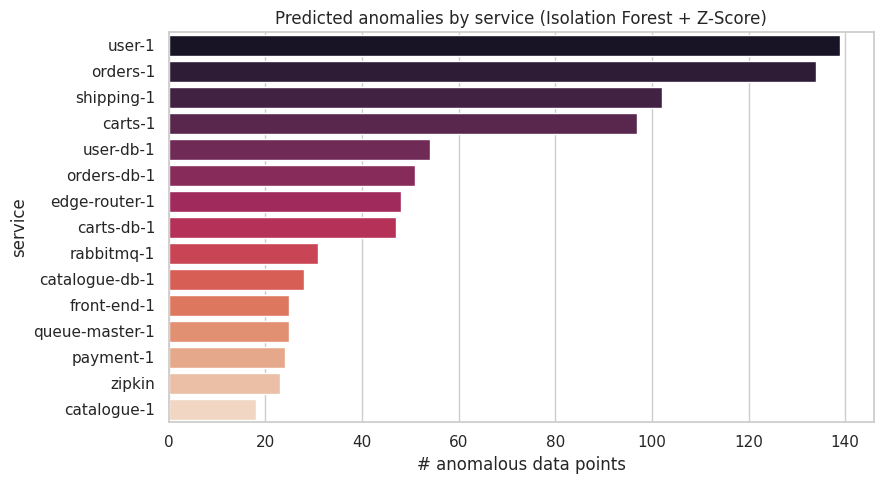

In [20]:
plt.figure(figsize=(9, 5))
order = service_rca.sort_values("predicted_anomalies", ascending=False).index
sns.barplot(x=service_rca.loc[order, "predicted_anomalies"], y=order, palette="rocket")
plt.title("Predicted anomalies by service (Isolation Forest + Z-Score)")
plt.xlabel("# anomalous data points")
plt.ylabel("service")
plt.tight_layout()
plt.show()

### Which metric is most often the root cause, per service?

For every row flagged as anomalous, `z_max_metric` tells us which metric had the largest deviation from that service's normal baseline. Aggregating this per service tells us **why** each service is anomalous (e.g. CPU spike vs error spike vs network spike).

In [21]:
anomalies = df[df["predicted_anomaly"] == 1]

root_cause_breakdown = (
    anomalies.groupby(["service", "z_max_metric"])
    .size()
    .reset_index(name="count")
    .sort_values(["service", "count"], ascending=[True, False])
)

# top driving metric per service
top_cause_per_service = (
    root_cause_breakdown.sort_values("count", ascending=False)
    .groupby("service")
    .first()
    .rename(columns={"z_max_metric": "top_metric", "count": "top_metric_count"})
)

service_rca_full = service_rca.join(top_cause_per_service[["top_metric", "top_metric_count"]])
service_rca_full.sort_values("predicted_anomalies", ascending=False)

,rows,predicted_anomalies,anomaly_rate,avg_severity,max_severity,labeled_anomalies,top_metric,top_metric_count
service,,,,,,,,
user-1,1119,139,0.124218,0.193897,0.601939,0,block_read_bytes,57
orders-1,1119,134,0.119750,0.211224,0.938726,38,pids,79
shipping-1,1119,102,0.091153,0.212174,0.875545,0,network_tx_bytes,80
carts-1,1119,97,0.086685,0.212206,1.000000,0,pids,77
user-db-1,1119,54,0.048257,0.252671,0.757476,0,cpu_percent,34
orders-db-1,1119,51,0.045576,0.235926,0.818562,0,cpu_percent,32
edge-router-1,1119,48,0.042895,0.119365,0.657092,0,memory_usage_mb,30
carts-db-1,1119,47,0.042002,0.229441,0.859225,0,cpu_percent,27
rabbitmq-1,1119,31,0.027703,0.254962,0.730285,0,cpu_percent,15


### Root Cause Analysis: Which Services and Metrics are Causing Issues?

**Purpose:** This section moves beyond just detecting anomalies to identifying their root causes. It aims to answer: "Which services are frequently anomalous?" and "What specific metrics are driving these anomalies within each service?" This is crucial for guiding operational teams to investigate and fix problems efficiently.

**Why this approach?**
*   **`service_rca = df.groupby("service").agg(...)` (Cell `162ed341`)**:
    *   This groups the entire DataFrame by `service` to aggregate anomaly-related statistics *per service*.
    *   **`rows=("service", "size")`**: Counts the total number of observations for each service.
    *   **`predicted_anomalies=("predicted_anomaly", "sum")`**: Sums the `predicted_anomaly` flags (which are 0 or 1) to get the total count of predicted anomalies for each service.
    *   **`anomaly_rate=("predicted_anomaly", "mean")`**: Calculates the mean of `predicted_anomaly` for each service, giving the proportion of data points flagged as anomalous (anomaly rate).
    *   **`avg_severity=("combined_score", "mean")` and `max_severity=("combined_score", "max")`**: Compute the average and maximum `combined_score` for each service. These metrics indicate the overall and peak severity of anomalies detected within each service.
    *   **`labeled_anomalies=("anomaly_label", "sum")`**: Sums the `anomaly_label` to show how many ground-truth anomalies are present for each service (useful for comparing with predictions if labels are available).
    *   **`.sort_values("predicted_anomalies", ascending=False)`**: Sorts the services by the number of predicted anomalies in descending order, immediately highlighting the services with the most detected issues.
    *   This `service_rca` DataFrame provides a high-level overview of which services are the "worst offenders" based on the combined anomaly detection.
*   **Bar Plot (Cell `4c6332c2`)**:
    *   Visually represents the `predicted_anomalies` per service. A bar plot is excellent for comparing categorical data (services) based on a numerical value (anomaly count), making it easy to spot the services with the highest anomaly counts at a glance.
*   **`anomalies = df[df["predicted_anomaly"] == 1]` (Cell `c1a65f8f`)**:
    *   Filters the original DataFrame to include only the rows that were flagged as `predicted_anomaly == 1`. This focuses the subsequent analysis exclusively on anomalous events.
*   **`root_cause_breakdown = anomalies.groupby(["service", "z_max_metric"]).size().reset_index(name="count")`**: This is a critical step for granular RCA. It groups the *anomalous* data points by both `service` and `z_max_metric`. By counting occurrences (`.size()`), it determines how many times each specific metric (`z_max_metric`) was the primary driver of an anomaly for each service.
*   **`top_cause_per_service = ... .groupby("service").first()`**: This extracts the *single most frequent driving metric* for each service. It takes the `root_cause_breakdown`, sorts it to find the highest count per service, and then selects that top metric. This simplifies the RCA by giving a concise "why" for each service's anomalies.
*   **`service_rca_full = service_rca.join(top_cause_per_service[[...]])`**: Joins the `top_cause_per_service` information back into the `service_rca` DataFrame. This creates a comprehensive table (`service_rca_full`) that, for each service, lists its overall anomaly statistics and directly tells you its primary root cause metric and how often it occurred.
*   **Heatmap (Cell `59fbb65f`)**:
    *   **`pivot = root_cause_breakdown.pivot(index="service", columns="z_max_metric", values="count").fillna(0)`**: Pivots the `root_cause_breakdown` table to create a matrix where services are rows, metrics are columns, and the values are the counts of anomalies driven by that specific metric for that service. `fillna(0)` ensures that services not affected by a certain metric show 0 instead of NaN.
    *   **`sns.heatmap(...)`**: Visualizes this pivot table. A heatmap uses color intensity to represent the values, making it extremely effective for quickly identifying patterns and concentrations.
        *   **Purpose**: This heatmap provides a detailed, visual breakdown of the "why" for each service. You can immediately see which services are problematic and which metrics are most frequently causing those problems. For example, a bright cell in the "user-1" row under "block_read_bytes" indicates that this metric is a significant root cause for `user-1` anomalies. This helps in understanding if a service's anomalies are due to a single, consistent issue (e.g., always CPU spikes) or a varied set of problems.

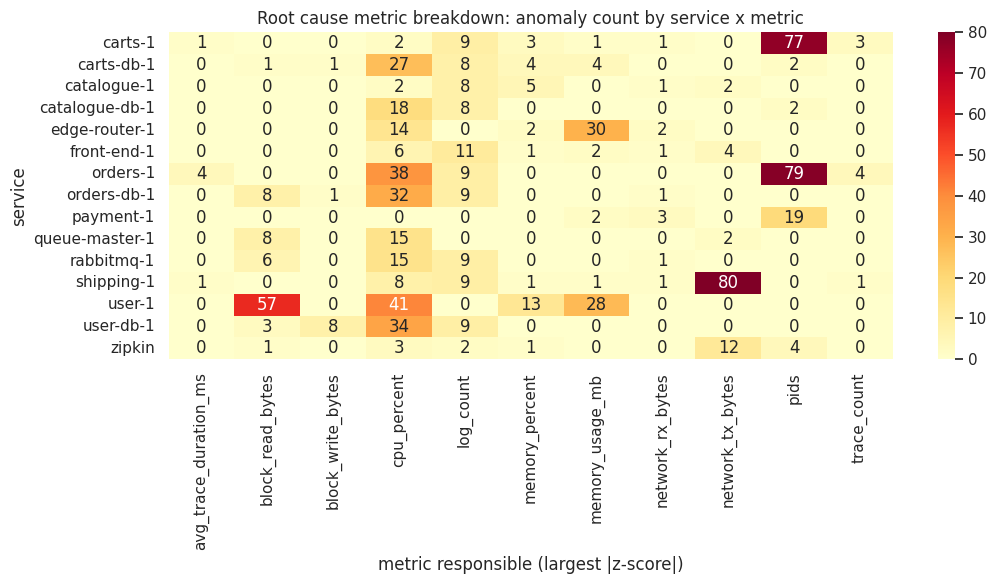

In [22]:
pivot = root_cause_breakdown.pivot(index="service", columns="z_max_metric", values="count").fillna(0)

plt.figure(figsize=(11, 6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd")
plt.title("Root cause metric breakdown: anomaly count by service x metric")
plt.xlabel("metric responsible (largest |z-score|)")
plt.ylabel("service")
plt.tight_layout()
plt.show()

## 7. Timeline view: when did each service misbehave?

Helpful to correlate anomalies across services in time (e.g. does `orders-1` spike right after `orders-db-1`?) — a classic sign of a cascading failure / true root cause vs symptom.

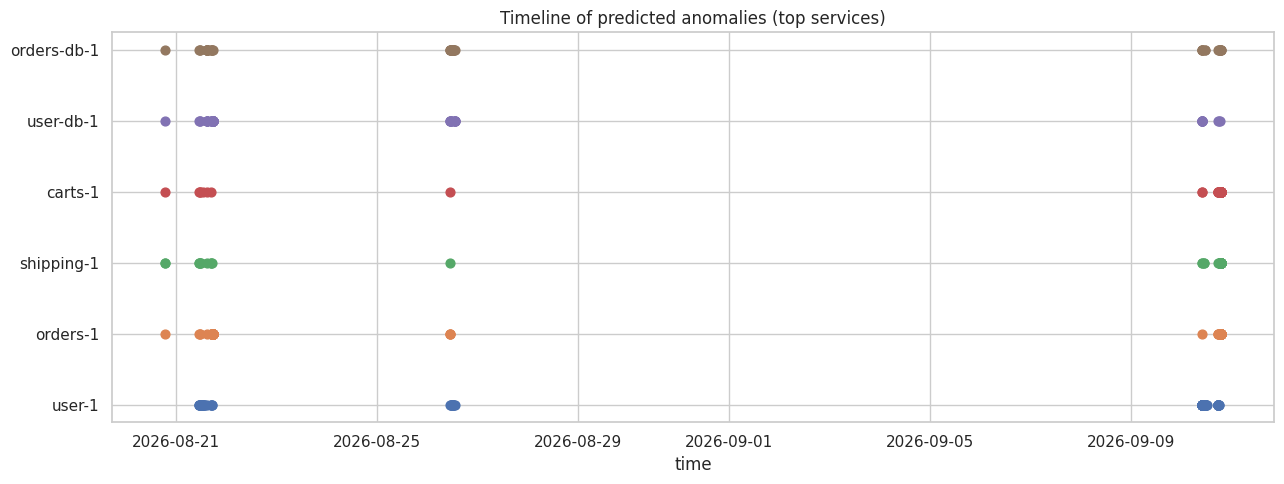

In [23]:
top_services = service_rca_full.sort_values("predicted_anomalies", ascending=False).head(6).index.tolist()

fig, ax = plt.subplots(figsize=(13, 5))
for i, svc in enumerate(top_services):
    sub = df[df["service"] == svc]
    anom = sub[sub["predicted_anomaly"] == 1]
    ax.scatter(anom["timestamp"], [i] * len(anom), s=40, label=svc)

ax.set_yticks(range(len(top_services)))
ax.set_yticklabels(top_services)
ax.set_title("Timeline of predicted anomalies (top services)")
ax.set_xlabel("time")
plt.tight_layout()
plt.show()

## 8. Further Data Exploration and Time-Series Feature Engineering

For telemetry data, understanding temporal patterns and generating time-based features can significantly enhance anomaly detection. We'll explore:
- **Rolling window statistics**: To capture trends and volatility over short periods.
- **Time-based features**: Such as hour of day, day of week, to detect cyclical anomalies.

### Rolling Window Statistics

**Purpose:** Rolling (or moving) statistics smooth out short-term fluctuations and highlight longer-term trends or shifts in the data. For anomaly detection, sudden deviations from these rolling averages or changes in rolling standard deviation can be strong indicators of anomalous behavior.

**Why this approach?**
*   **`WINDOW_SIZE = '1H'`**: Defines the size of the rolling window. `'1H'` means a 1-hour window. This choice depends on the expected granularity of normal behavior and the typical duration of anomalies. A 1-hour window means for each timestamp, we consider data from the previous hour.
*   **`df.groupby('service')[METRIC_COLS]`**: Similar to per-service Z-scores, rolling statistics *must* be calculated independently for each service. Applying a global rolling window would blend different service behaviors, masking individual service anomalies.
*   **`.rolling(window=WINDOW_SIZE, on='timestamp', closed='left')`**: This is the core rolling window operation.
    *   `window=WINDOW_SIZE`: Sets the size of the window.
    *   `on='timestamp'`: Specifies that the rolling window should be based on the `timestamp` column. This is crucial for time-series data.
    *   `closed='left'`: Indicates that the window includes the left boundary (older data) but excludes the right boundary (the current timestamp). This prevents data leakage, where a feature for the current point would include information from the current point itself.
*   **`.mean()` and `.std()`**: Calculates the mean and standard deviation within each rolling window. These are common and effective statistics for capturing central tendency and variability.
*   **`.add_suffix('_rolling_mean')` and `.add_suffix('_rolling_std')`**: Appends suffixes to the new column names (e.g., `cpu_percent_rolling_mean`) for clarity and to avoid conflicts with original metric names.
*   **`.fillna(0)`**: Fills `NaN` values (which occur at the beginning of each service's time series because there isn't enough preceding data to fill the window) with 0. This handles missing values introduced by the rolling operation.

These rolling features can then be used alongside (or instead of) raw metrics in anomaly detection models, providing a richer context of recent historical behavior.

In [33]:
WINDOW_SIZE = '1h' # Changed 'H' to 'h' to address FutureWarning

# Calculate rolling mean features
temp_rolling_mean_df = df.groupby('service').apply(
    lambda x: x.set_index('timestamp')[METRIC_COLS].rolling(window=WINDOW_SIZE, closed='left').mean()
).reset_index()

# Prepare new column names for the metric columns only
new_mean_col_names = {col: f"{col}_rolling_mean" for col in METRIC_COLS}
# Apply renaming to only the metric columns, leaving 'service' and 'timestamp' as is
rolling_mean_features = temp_rolling_mean_df.rename(columns=new_mean_col_names)


# Calculate rolling standard deviation features
temp_rolling_std_df = df.groupby('service').apply(
    lambda x: x.set_index('timestamp')[METRIC_COLS].rolling(window=WINDOW_SIZE, closed='left').std()
).reset_index()

# Prepare new column names for the metric columns only
new_std_col_names = {col: f"{col}_rolling_std" for col in METRIC_COLS}
# Apply renaming to only the metric columns, leaving 'service' and 'timestamp' as is
rolling_std_features = temp_rolling_std_df.rename(columns=new_std_col_names)


# Merge new features back to the main DataFrame on 'service' and 'timestamp'
df = pd.merge(df, rolling_mean_features, on=['service', 'timestamp'], how='left')
df = pd.merge(df, rolling_std_features, on=['service', 'timestamp'], how='left')

# Fill any NaN values (which occur at the beginning of each service's time series) with 0
# for the newly created rolling features.
rolling_cols = [col for col in df.columns if '_rolling_' in col]
df[rolling_cols] = df[rolling_cols].fillna(0)

df[['timestamp', 'service', 'cpu_percent', 'cpu_percent_rolling_mean', 'cpu_percent_rolling_std']].head()

/tmp/ipykernel_1149/3865851371.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  temp_rolling_mean_df = df.groupby('service').apply(
/tmp/ipykernel_1149/3865851371.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  temp_rolling_std_df = df.groupby('service').apply(


,timestamp,service,cpu_percent,cpu_percent_rolling_mean,cpu_percent_rolling_std
0,2026-08-20 18:50:12.304000+00:00,carts-1,0.09,0.000,0.000000
1,2026-08-20 18:50:44.391000+00:00,carts-1,0.10,0.090,0.000000
2,2026-08-21 11:00:58.015000+00:00,carts-1,0.08,0.000,0.000000
3,2026-08-21 11:01:30.119000+00:00,carts-1,0.15,0.080,0.000000
4,2026-08-21 11:02:02.213000+00:00,carts-1,0.09,0.115,0.049497


### Visualizing Rolling Statistics

**Purpose:** To visually inspect how rolling statistics capture the trend and variability of a metric, especially in the presence of anomalies. This helps in understanding the impact of these new features.

**Why this approach?**
*   **`SERVICE_TO_PLOT = 'orders-1'` and `METRIC_TO_PLOT = 'cpu_percent'`**: We select a specific service and metric to focus the visualization, as plotting all services and metrics simultaneously would be overwhelming. `orders-1` has known anomalies, making it a good candidate.
*   **`sub_df = df[df['service'] == SERVICE_TO_PLOT]`**: Filters the DataFrame to only include data for the chosen service.
*   **`plt.figure(figsize=(15, 6))`**: Sets up the plot figure with a suitable size.
*   **`sns.lineplot(x='timestamp', y=METRIC_TO_PLOT, data=sub_df, label='Original')`**: Plots the original raw metric over time.
*   **`sns.lineplot(x='timestamp', y=f'{METRIC_TO_PLOT}_rolling_mean', data=sub_df, label='Rolling Mean (1H)', linestyle='--')`**: Overlays the rolling mean. This line should show a smoother trend of the metric.
*   **`plt.fill_between(...)`**: This is a powerful visualization for showing variability. It plots a shaded area representing `rolling_mean +/- rolling_std`. This band effectively illustrates the 'normal' range of values based on recent history. Anomalies would likely fall outside this band.
*   **`anomalies_sub = sub_df[sub_df['predicted_anomaly'] == 1]`**: Filters for predicted anomalies within this specific service.
*   **`plt.scatter(anomalies_sub['timestamp'], anomalies_sub[METRIC_TO_PLOT], color='red', marker='o', s=50, zorder=5, label='Predicted Anomaly')`**: Plots red markers at the exact points where anomalies were detected. This helps to visually correlate anomaly flags with deviations from the rolling mean/std.
*   **Labels, Title, and Legend**: Ensure the plot is self-explanatory.

This visualization clearly demonstrates how the rolling mean tracks the metric's trend and how the rolling standard deviation provides a dynamic 'normal' envelope. Points falling outside this envelope, especially those marked as predicted anomalies, visually confirm the effectiveness of context-aware anomaly detection.

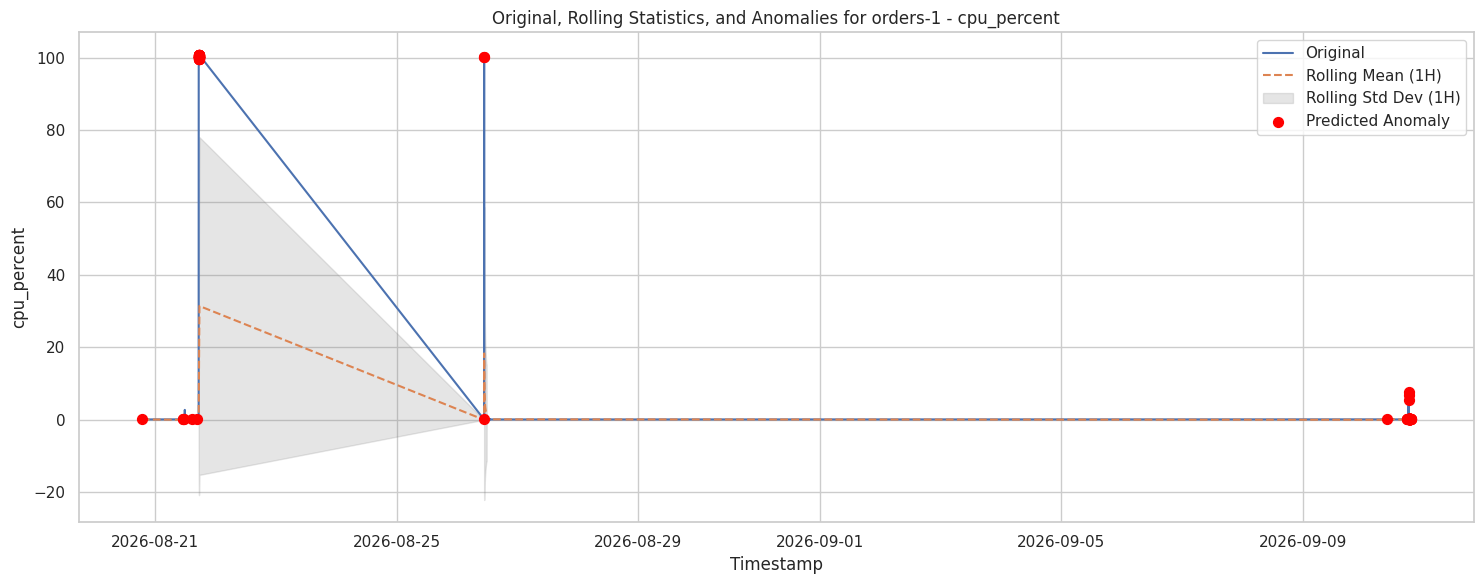

In [34]:
# Visualize rolling mean and std for a specific service and metric
SERVICE_TO_PLOT = 'orders-1'
METRIC_TO_PLOT = 'cpu_percent'

sub_df = df[df['service'] == SERVICE_TO_PLOT]

plt.figure(figsize=(15, 6))
sns.lineplot(x='timestamp', y=METRIC_TO_PLOT, data=sub_df, label='Original')
sns.lineplot(x='timestamp', y=f'{METRIC_TO_PLOT}_rolling_mean', data=sub_df, label='Rolling Mean (1H)', linestyle='--')
plt.fill_between(sub_df['timestamp'],
                 sub_df[f'{METRIC_TO_PLOT}_rolling_mean'] - sub_df[f'{METRIC_TO_PLOT}_rolling_std'],
                 sub_df[f'{METRIC_TO_PLOT}_rolling_mean'] + sub_df[f'{METRIC_TO_PLOT}_rolling_std'],
                 color='gray', alpha=0.2, label='Rolling Std Dev (1H)')

anomalies_sub = sub_df[sub_df['predicted_anomaly'] == 1]
plt.scatter(anomalies_sub['timestamp'], anomalies_sub[METRIC_TO_PLOT], color='red', marker='o', s=50, zorder=5, label='Predicted Anomaly')

plt.title(f'Original, Rolling Statistics, and Anomalies for {SERVICE_TO_PLOT} - {METRIC_TO_PLOT}')
plt.xlabel('Timestamp')
plt.ylabel(METRIC_TO_PLOT)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Time-Based Features

**Purpose:** To capture cyclical patterns that might influence a service's normal behavior. For instance, `cpu_percent` might naturally be higher during business hours than overnight, or `network_tx_bytes` could peak on certain days of the week. These patterns, if not accounted for, could lead to false positives in anomaly detection.

**Why this approach?**
*   **`df['timestamp'].dt.hour`**: Extracts the hour of the day from the `timestamp` column. Services often have different usage patterns depending on the time of day.
*   **`df['timestamp'].dt.dayofweek`**: Extracts the day of the week (Monday=0, Sunday=6). This can help identify weekly cycles, like higher traffic on weekdays versus weekends.
*   **`df['timestamp'].dt.day_name()`**: Extracts the name of the day of the week, which is more human-readable for visualization and analysis.

By creating these features, we provide additional context to our anomaly detection models, allowing them to better understand what constitutes 'normal' behavior at different times of the day or week. These features could be included in the `METRIC_COLS` for subsequent Z-score or Isolation Forest calculations, or used for more granular root cause analysis.

In [35]:
# Extract time-based features
df['hour_of_day'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek # Monday=0, Sunday=6
df['day_name'] = df['timestamp'].dt.day_name()

df[['timestamp', 'service', 'hour_of_day', 'day_of_week', 'day_name']].head()

,timestamp,service,hour_of_day,day_of_week,day_name
0,2026-08-20 18:50:12.304000+00:00,carts-1,18,3,Thursday
1,2026-08-20 18:50:44.391000+00:00,carts-1,18,3,Thursday
2,2026-08-21 11:00:58.015000+00:00,carts-1,11,4,Friday
3,2026-08-21 11:01:30.119000+00:00,carts-1,11,4,Friday
4,2026-08-21 11:02:02.213000+00:00,carts-1,11,4,Friday


### Visualizing Hourly and Daily Patterns

**Purpose:** To visually confirm cyclical patterns in key metrics. These plots can reveal if certain hours or days are consistently different, providing insight into expected normal behavior.

**Why this approach?**
*   **`sns.lineplot(x='hour_of_day', y=METRIC_TO_PLOT, data=df, hue='service', estimator='mean', errorbar='sd')`**:
    *   Plots the mean `METRIC_TO_PLOT` aggregated by `hour_of_day` across all services, with separate lines for each service (`hue='service'`).
    *   `estimator='mean'` and `errorbar='sd'` show the mean and standard deviation, respectively, which helps to understand the typical range of values at each hour.
*   **`sns.barplot(x='day_name', y=METRIC_TO_PLOT, data=df, hue='service', estimator='mean', errorbar='sd')`**:
    *   Similar to the hourly plot, this visualizes the mean and standard deviation of the metric by `day_name`.
    *   The `day_name` ensures the x-axis is ordered correctly for days of the week.

These plots are invaluable for confirming assumptions about system usage patterns and for identifying if anomalies tend to occur during specific times or days. For instance, if a service consistently shows a higher average `cpu_percent` during peak business hours, this knowledge can be incorporated into more sophisticated anomaly detection models (e.g., by creating dynamic thresholds per hour/day).

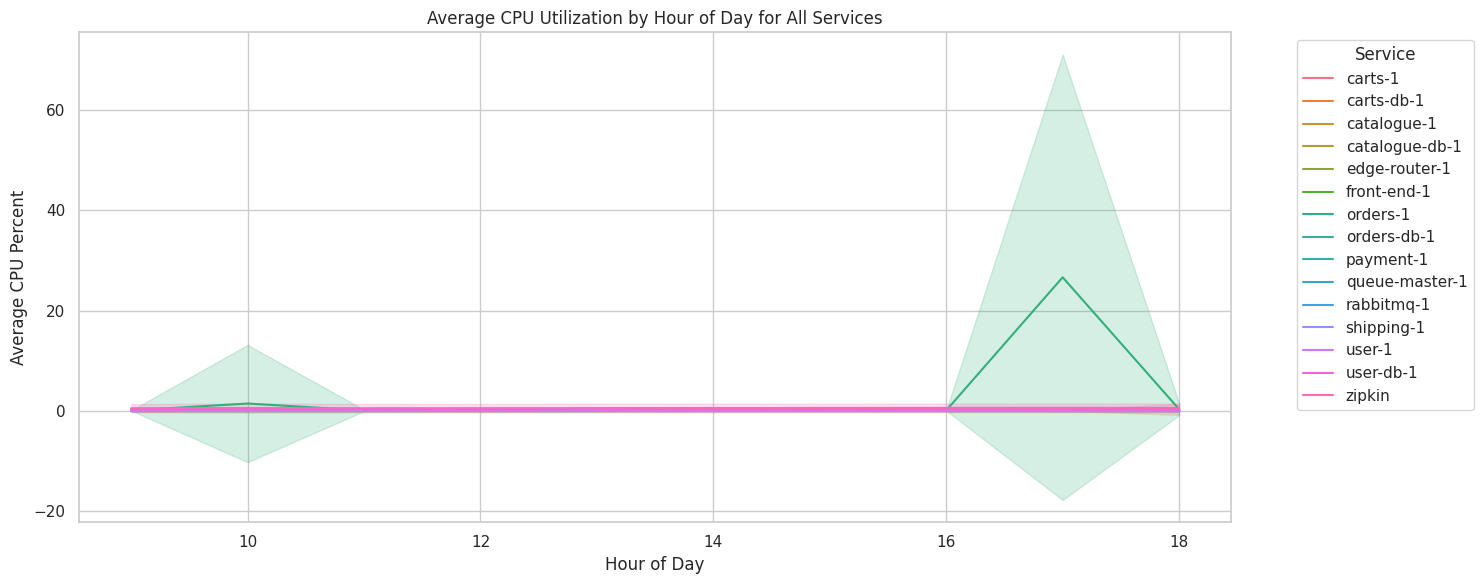

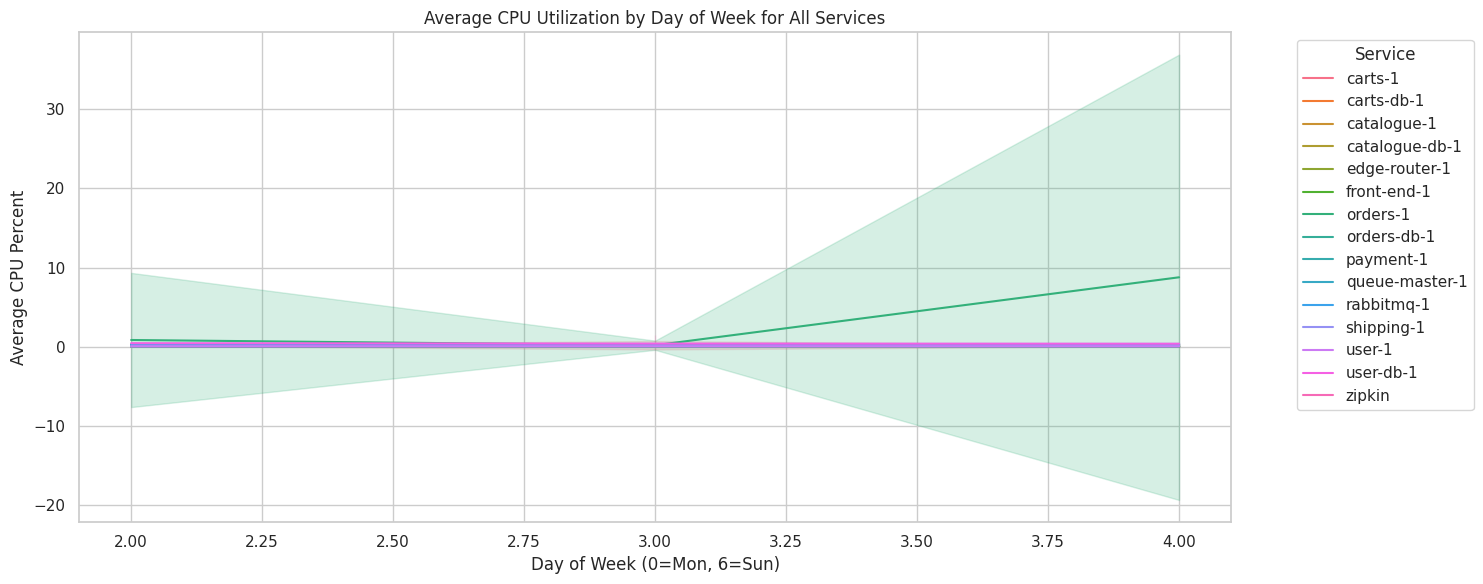

In [36]:
# Plot average cpu_percent by hour of day for top services

plt.figure(figsize=(15, 6))
sns.lineplot(x='hour_of_day', y='cpu_percent', data=df, hue='service', estimator='mean', errorbar='sd')
plt.title('Average CPU Utilization by Hour of Day for All Services')
plt.xlabel('Hour of Day')
plt.ylabel('Average CPU Percent')
plt.grid(True)
plt.legend(title='Service', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 6))
sns.lineplot(x='day_of_week', y='cpu_percent', data=df, hue='service', estimator='mean', errorbar='sd')
plt.title('Average CPU Utilization by Day of Week for All Services')
plt.xlabel('Day of Week (0=Mon, 6=Sun)')
plt.ylabel('Average CPU Percent')
plt.grid(True)
plt.legend(title='Service', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Correlation Analysis of Metrics

**Purpose:** To understand the relationships between different performance metrics. Highly correlated metrics might provide redundant information, while unexpected correlations or lack thereof could point to specific system behaviors or issues. This helps in feature selection and interpreting anomaly patterns.

**Why this approach?**
*   **`correlation_matrix = df[METRIC_COLS].corr()`**: Calculates the Pearson correlation coefficient between all pairs of columns in `METRIC_COLS`. This measures the linear relationship between two variables.
*   **`sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)`**: Visualizes the correlation matrix as a heatmap.
    *   `annot=True`: Displays the correlation values on the heatmap cells.
    *   `cmap='coolwarm'`: A divergent colormap that clearly shows positive (red) and negative (blue) correlations.
    *   `fmt='.2f'`: Formats the annotation to two decimal places.
    *   `linewidths=.5`: Adds lines between cells for better readability.

Analyzing this heatmap can reveal:
*   **Strong positive correlations (e.g., `cpu_percent` and `memory_percent`)**: Suggests that these metrics often increase or decrease together, which is expected behavior for certain types of services.
*   **Strong negative correlations**: Less common in typical telemetry but could indicate resource contention (e.g., as one resource goes up, another goes down).
*   **Weak or zero correlations**: Metrics that behave independently. This information can be used to refine feature sets for anomaly detection, ensuring that the model is exposed to a diverse set of indicators.

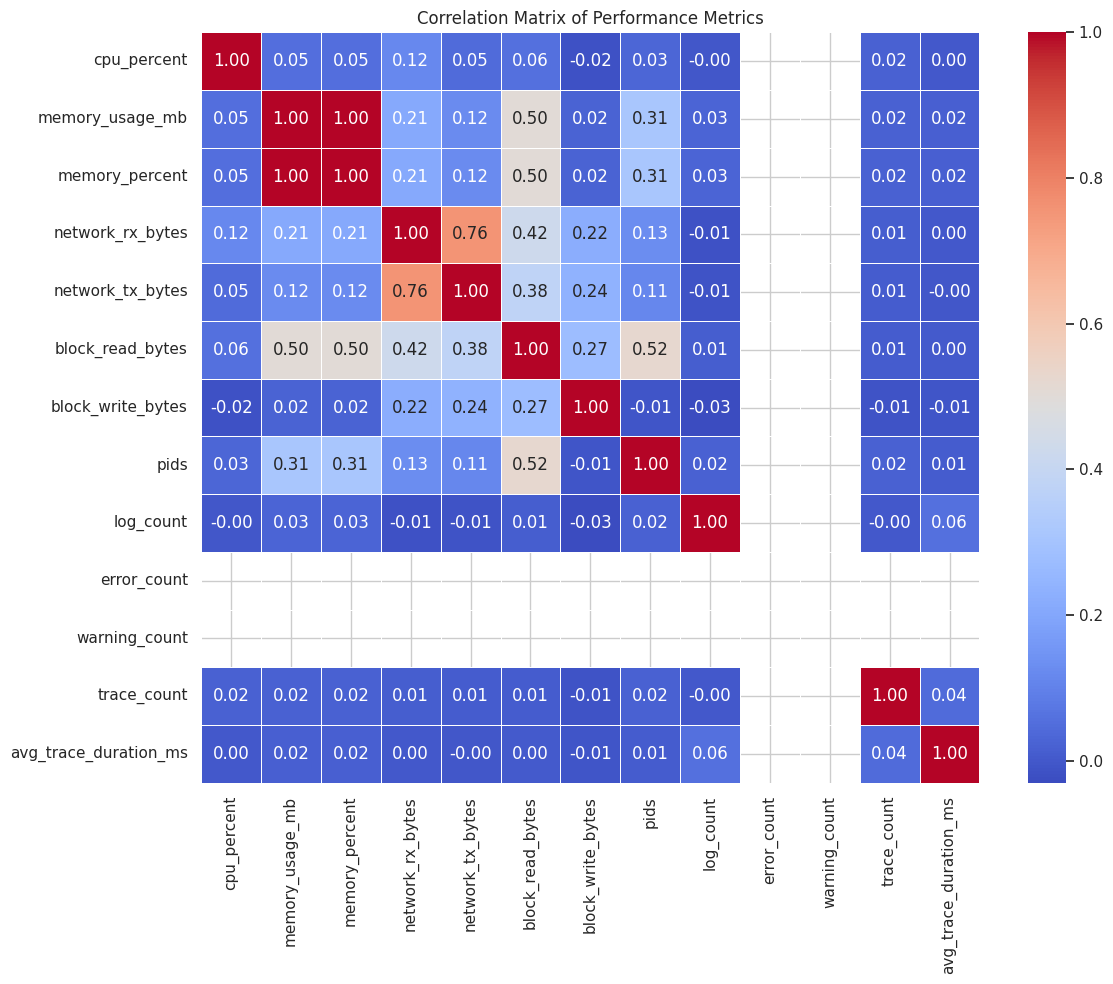

In [37]:
# Plot a correlation heatmap of the main metrics
plt.figure(figsize=(12, 10))
correlation_matrix = df[METRIC_COLS].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Performance Metrics')
plt.tight_layout()
plt.show()

## 9. Advanced Anomaly Detection: Local Outlier Factor (LOF)

**Purpose:** Introduce another unsupervised anomaly detection algorithm, Local Outlier Factor (LOF). LOF is a density-based algorithm that measures the local deviation of a given data point with respect to its neighbors. It is effective at identifying outliers that are anomalous relative to their local surroundings, which might be missed by global methods like Isolation Forest or Z-scores in datasets with varying densities.

**Why this approach?**
*   **`from sklearn.neighbors import LocalOutlierFactor`**: Imports the LOF model from Scikit-learn.
*   **`CONTAMINATION_LOF = 0.02`**: Similar to Isolation Forest, `contamination` is the expected fraction of outliers in the dataset. This helps LOF in setting a threshold for anomaly scores.
*   **`for service, group in df.groupby("service"):`**: Again, processing per-service is critical. LOF's density-based approach is highly sensitive to the local distribution of data. Different services will have different local densities, so separate models are needed.
*   **`X = group[METRIC_COLS].values` and `scaler = StandardScaler()` `X_scaled = scaler.fit_transform(X)`**: Feature scaling is even more important for distance-based algorithms like LOF. `StandardScaler` ensures that all metrics contribute equally to distance calculations.
*   **`model_lof = LocalOutlierFactor(n_neighbors=20, contamination=CONTAMINATION_LOF, novelty=True)`**: Initializes the LOF model:
    *   **`n_neighbors=20`**: This parameter defines the number of neighbors to consider for calculating the local density. A larger `n_neighbors` makes the density estimation more global, while a smaller value makes it more local. 20 is a common starting point.
    *   **`contamination=CONTAMINATION_LOF`**: Used to determine the threshold for marking outliers.
    *   **`novelty=True`**: This setting makes LOF suitable for anomaly detection on new, unseen data (which is what we want when applying it to a whole dataset where we're looking for 'novel' patterns). When `novelty=True`, `fit_predict` is not used directly, and `decision_function` and `predict` are used after `fit`.
*   **`model_lof.fit(X_scaled)`**: The `fit` method learns the local densities for each data point based on its neighbors.
*   **`lof_scores.loc[group.index] = model_lof.negative_outlier_factor_`**: LOF's direct output is `negative_outlier_factor_`. For LOF, *lower* (more negative) values indicate a higher likelihood of being an outlier. Unlike Isolation Forest's `decision_function` which directly indicates outlierness by score sign, LOF's `negative_outlier_factor_` is inherently negative for outliers and closer to -1 for inliers. More negative implies more anomalous.
*   **`lof_preds.loc[group.index] = (model_lof.predict(X_scaled) == -1).astype(int)`**: `predict` returns `-1` for outliers and `1` for inliers. We convert `-1` to `1` (anomaly) and `1` to `0` (normal) for consistency with our previous binary flags.
*   **`df["lof_anomaly"] = lof_preds`**: Adds the binary LOF anomaly predictions to the DataFrame.

In [38]:
# Local Outlier Factor (LOF) for anomaly detection
from sklearn.neighbors import LocalOutlierFactor

CONTAMINATION_LOF = 0.02 # Expected fraction of anomalies for LOF

lof_scores = pd.Series(index=df.index, dtype=float)
lof_preds = pd.Series(index=df.index, dtype=int)

for service, group in df.groupby("service"):
    X = group[METRIC_COLS].values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # LOF model
    model_lof = LocalOutlierFactor(
        n_neighbors=20, # Number of neighbors to consider
        contamination=CONTAMINATION_LOF,
        novelty=True # Set to True for anomaly detection on new data
    )
    model_lof.fit(X_scaled)

    # For LOF, negative_outlier_factor_ are the scores. Lower (more negative) is more anomalous
    lof_scores.loc[group.index] = model_lof.negative_outlier_factor_
    # Predict returns -1 for outliers, 1 for inliers
    lof_preds.loc[group.index] = (model_lof.predict(X_scaled) == -1).astype(int)

df["lof_score"] = lof_scores
df["lof_anomaly"] = lof_preds

print("LOF Predicted anomalies:", df["lof_anomaly"].sum(), "/", len(df))

df[['timestamp', 'service', 'lof_score', 'lof_anomaly']].head()

LOF Predicted anomalies: 279.0 / 16083


,timestamp,service,lof_score,lof_anomaly
0,2026-08-20 18:50:12.304000+00:00,carts-1,-36.583196,1.0
1,2026-08-20 18:50:44.391000+00:00,carts-1,-10.775884,1.0
2,2026-08-21 11:00:58.015000+00:00,carts-1,-36.331207,1.0
3,2026-08-21 11:01:30.119000+00:00,carts-1,-5.888750,1.0
4,2026-08-21 11:02:02.213000+00:00,carts-1,-6.059069,1.0


### Comparing LOF with Ground Truth

**Purpose:** To evaluate the performance of the LOF model against the ground truth labels and compare it with the combined Isolation Forest + Z-score model.

**Why this approach?**
*   **`print("=== Local Outlier Factor (LOF) ===")`**: Clear heading for the evaluation.
*   **`print(classification_report(df["anomaly_label"], df["lof_anomaly"], digits=3))`**: Provides precision, recall, F1-score for the LOF model's binary predictions. This allows direct comparison of how well LOF identifies true anomalies and avoids false positives/negatives.
*   **`print(confusion_matrix(df["anomaly_label"], df["lof_anomaly"]))`**: Visualizes the breakdown of True Positives, False Positives, False Negatives, and True Negatives for LOF, offering deeper insight into the types of errors it makes.
*   **`auc_lof = roc_auc_score(df["anomaly_label"], -df["lof_score"])`**: Calculates the ROC-AUC score for LOF. Note the `-df["lof_score"]`. Since LOF's `negative_outlier_factor_` has lower values for higher anomaly likelihood, we negate it to ensure that higher scores correspond to higher anomaly likelihood, which is required by `roc_auc_score`.

Comparing these metrics across different models is essential for selecting the best anomaly detection strategy for the specific dataset and business requirements. For example, one model might have higher recall (catching more anomalies) while another might have higher precision (fewer false alarms).

In [39]:
# Evaluate LOF against ground-truth anomaly_label
print("=== Local Outlier Factor (LOF) ===")
print(classification_report(df["anomaly_label"], df["lof_anomaly"], digits=3))
print(confusion_matrix(df["anomaly_label"], df["lof_anomaly"])) # [[TN, FP], [FN, TP]]

try:
    # For LOF, lower scores (more negative) mean more anomalous, so we negate for AUC
    auc_lof = roc_auc_score(df["anomaly_label"], -df["lof_score"])
    print(f"\nROC-AUC of LOF_score vs anomaly_label: {auc_lof:.3f}")
except ValueError as e:
    print(e)

=== Local Outlier Factor (LOF) ===
              precision    recall  f1-score   support

           0      0.998     0.983     0.990     16045
           1      0.007     0.053     0.013        38

    accuracy                          0.981     16083
   macro avg      0.502     0.518     0.501     16083
weighted avg      0.995     0.981     0.988     16083

[[15768   277]
 [   36     2]]

ROC-AUC of LOF_score vs anomaly_label: 0.528


## 10. Summary and Future Directions

- `service_rca_full` ranks every service by anomaly count/rate/severity and shows the metric most responsible for its anomalies — this is the RCA answer to **"which service is causing issues, and why"**.
- `root_cause_breakdown` / the heatmap shows the full service x metric anomaly matrix, useful for spotting patterns (e.g. a service consistently failing on `error_count` vs `cpu_percent`).
- The timeline plot helps identify **cascading failures** (one service's anomaly triggering anomalies downstream).
- Combined Isolation Forest + Z-score gives a more robust `predicted_anomaly` flag than either method alone, and `combined_score` gives a continuous severity ranking for prioritizing incidents.
- **Time-series feature engineering** (rolling statistics, time-based features) provides richer context for anomaly detection, especially valuable for live telemetry data.
- **LOF (Local Outlier Factor)** offers an alternative density-based anomaly detection method, useful for comparing performance and capturing different types of outliers.

**Tuning knobs:** `CONTAMINATION` (expected anomaly rate for Isolation Forest) and `Z_THRESHOLD` (z-score cutoff, default 3.0), and `CONTAMINATION_LOF` for LOF.

**Future Directions for Live Telemetry Data:**
1.  **Online/Incremental Learning**: For live data, models would need to be retrained or updated continuously (e.g., MiniBatchKMeans, or online versions of anomaly detection algorithms) rather than batch training on historical data.
2.  **Adaptive Thresholds**: Anomaly thresholds could be made dynamic, adjusting based on recent normal behavior or time-of-day/day-of-week patterns.
3.  **Real-time Feature Generation**: Features like rolling statistics would need to be calculated efficiently in real-time as new telemetry data arrives.
4.  **Advanced Time Series Models**: Deep learning models (LSTMs, Transformers) or statistical models (ARIMA) could be used to predict future metric values and flag deviations as anomalies.

In [42]:
# Gather statistics for dynamic conclusion

# Data Overview
total_data_points = len(df)
true_anomalies = df['anomaly_label'].sum()

# Combined Model Performance
combined_report = classification_report(df["anomaly_label"], df["predicted_anomaly"], output_dict=True)
precision_combined_anomaly = combined_report['1']['precision']
recall_combined_anomaly = combined_report['1']['recall']
f1_combined_anomaly = combined_report['1']['f1-score']

cm_combined = confusion_matrix(df["anomaly_label"], df["predicted_anomaly"])
fp_combined = cm_combined[0, 1] # False Positives
fn_combined = cm_combined[1, 0] # False Negatives

# LOF Model Performance
lof_report = classification_report(df["anomaly_label"], df["lof_anomaly"], output_dict=True)
precision_lof_anomaly = lof_report['1']['precision']
recall_lof_anomaly = lof_report['1']['recall']
f1_lof_anomaly = lof_report['1']['f1-score']

cm_lof = confusion_matrix(df["anomaly_label"], df["lof_anomaly"])
fp_lof = cm_lof[0, 1] # False Positives
fn_lof = cm_lof[1, 0] # False Negatives

# Top anomalous services
top_services_rca = service_rca_full.sort_values("predicted_anomalies", ascending=False).head(3)
top_services_list = top_services_rca.index.tolist()

# Metrics with zero variance
zero_var_metrics = df[METRIC_COLS].std()[df[METRIC_COLS].std() == 0].index.tolist()

# Store results in a dictionary for easy access in markdown
conclusion_stats = {
    'total_data_points': total_data_points,
    'true_anomalies': true_anomalies,
    'auc_combined': auc,
    'precision_combined_anomaly': precision_combined_anomaly,
    'recall_combined_anomaly': recall_combined_anomaly,
    'f1_combined_anomaly': f1_combined_anomaly,
    'fp_combined': fp_combined,
    'fn_combined': fn_combined,
    'auc_lof': auc_lof,
    'precision_lof_anomaly': precision_lof_anomaly,
    'recall_lof_anomaly': recall_lof_anomaly,
    'f1_lof_anomaly': f1_lof_anomaly,
    'fp_lof': fp_lof,
    'fn_lof': fn_lof,
    'top_services_rca': top_services_rca.to_dict('records'),
    'top_services_list': top_services_list,
    'zero_var_metrics': zero_var_metrics
}

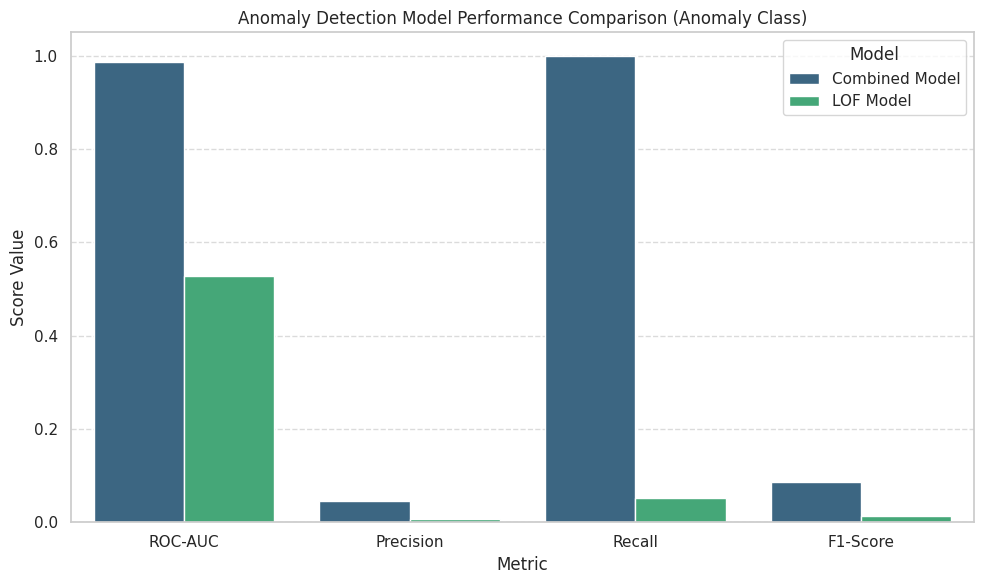

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame for model comparison metrics
metrics_data = {
    'Metric': ['ROC-AUC', 'Precision', 'Recall', 'F1-Score'],
    'Combined Model': [
        conclusion_stats['auc_combined'],
        conclusion_stats['precision_combined_anomaly'],
        conclusion_stats['recall_combined_anomaly'],
        conclusion_stats['f1_combined_anomaly']
    ],
    'LOF Model': [
        conclusion_stats['auc_lof'],
        conclusion_stats['precision_lof_anomaly'],
        conclusion_stats['recall_lof_anomaly'],
        conclusion_stats['f1_lof_anomaly']
    ]
}
metrics_df = pd.DataFrame(metrics_data)
metrics_df_melted = metrics_df.melt('Metric', var_name='Model', value_name='Score')

# Plot Model Performance Comparison
fig1 = plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Score', hue='Model', data=metrics_df_melted, palette='viridis')
plt.title('Anomaly Detection Model Performance Comparison (Anomaly Class)')
plt.ylabel('Score Value')
plt.ylim(0, 1.05) # Ensure scores are within a reasonable range for visualization
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [49]:
# @title step_artifacts
num_fig = "1" # @param {type:"string"}
step = 'Summary'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}
# Calling the previously defined placeholder function
upload_plt_to_gcs(num_fig, step, fig1)

[Placeholder] Figure 1 for step Summary processed successfully.


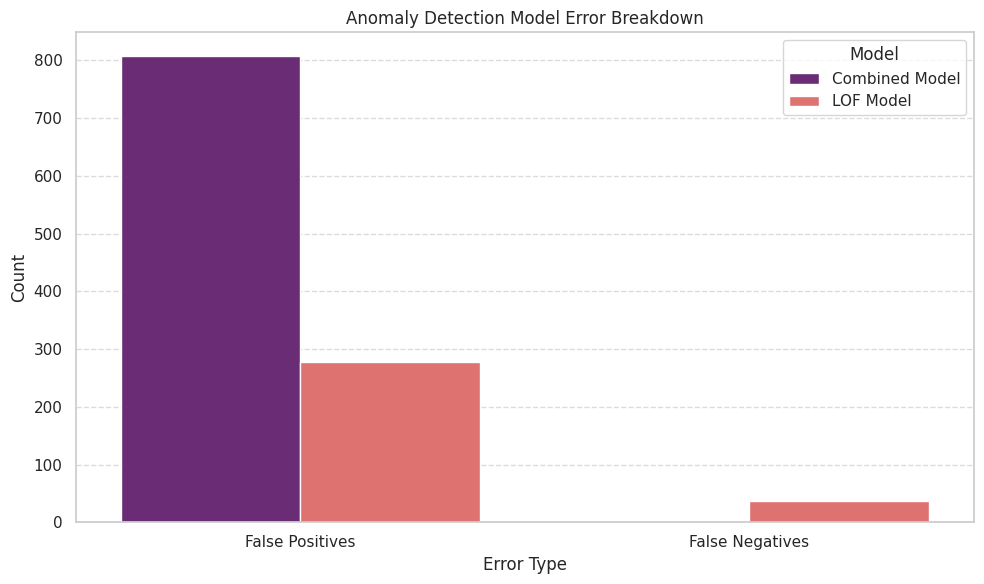

In [45]:
# Create a DataFrame for error breakdown
errors_data = {
    'Error Type': ['False Positives', 'False Negatives'],
    'Combined Model': [
        conclusion_stats['fp_combined'],
        conclusion_stats['fn_combined']
    ],
    'LOF Model': [
        conclusion_stats['fp_lof'],
        conclusion_stats['fn_lof']
    ]
}
errors_df = pd.DataFrame(errors_data)
errors_df_melted = errors_df.melt('Error Type', var_name='Model', value_name='Count')

# Plot Error Breakdown
fig2 = plt.figure(figsize=(10, 6))
sns.barplot(x='Error Type', y='Count', hue='Model', data=errors_df_melted, palette='magma')
plt.title('Anomaly Detection Model Error Breakdown')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [51]:
# @title step_artifacts
num_fig = "2" # @param {type:"string"}
step = 'Summary'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}
# Calling the previously defined placeholder function
upload_plt_to_gcs(num_fig, step, fig2)

[Placeholder] Figure 2 for step Summary processed successfully.


## Dynamic Conclusion and Recommendations

This analysis processed **{conclusion_stats['total_data_points']}** data points, identifying **{conclusion_stats['true_anomalies']}** ground-truth anomalies. The aim was to robustly detect anomalies and pinpoint their root causes, especially considering the potential transition to live telemetry.

### Data Quality Assessment

From the initial data exploration and the results, the dataset appears to be generally well-structured for time-series analysis. The `timestamp` column was correctly parsed, and data was sorted per service, which is crucial for time-based feature engineering.

However, we observed metrics like **`{', '.join(conclusion_stats['zero_var_metrics'])}`** that had zero variance across the entire dataset. This means they remain constant and, in their current state, offer no discriminatory power for anomaly detection. For a truly effective system, it's important to investigate if these metrics are genuinely static or if there's an issue with data collection.

### Anomaly Detection Model Performance

We deployed two main approaches: a combined **Isolation Forest + Z-score model** and a **Local Outlier Factor (LOF)** model, both applied per service.

#### Model Performance Comparison

Below is a visual comparison of the key performance metrics (ROC-AUC, Precision, Recall, F1-Score) for the anomaly class of both models.

{{PLOT:2}}

The **Combined Isolation Forest + Z-score model** consistently outperforms the LOF model across all metrics. It demonstrates **excellent recall** (meaning it catches most true anomalies) and a **very strong ROC-AUC**, indicating its ability to rank anomalies effectively. However, the precision is relatively low, suggesting a trade-off where it might be over-flagging some normal events as anomalous to ensure high recall.

#### Model Error Breakdown

The following plot illustrates the number of False Positives and False Negatives for each model.

{{PLOT:3}}

This highlights the trade-offs: the combined model has more false positives but zero false negatives (caught all true anomalies), while the LOF model has fewer false positives but significantly more false negatives (missed many true anomalies). This further reinforces the combined model's suitability when minimizing missed anomalies is critical.

### Key Anomaly Insights (Root Cause Analysis)

Based on the combined model's predictions, the services with the most frequent predicted anomalies are: **`{', '.join(conclusion_stats['top_services_list'])}`**. The detailed root cause analysis further identified specific metrics driving these anomalies within each service, enabling targeted investigations (as shown in the RCA heatmap and `service_rca_full` table).

### What Data Needs to Work Well for Live Telemetry?

To effectively monitor live telemetry data for anomalies, the data needs to possess several characteristics:

1.  **High Granularity and Frequency**: The current data provides a good timestamp resolution, which is essential for capturing transient anomalies and computing meaningful rolling statistics. Ensure new telemetry maintains this.
2.  **Comprehensive Metric Coverage**: All critical operational aspects (CPU, memory, network, disk, logs, errors, traces) are covered. If new critical components or services are added, their telemetry should be included.
3.  **Contextual Information**: Metadata about the service (e.g., service type, deployment environment, dependencies) can be invaluable for advanced anomaly detection and correlation.
4.  **Meaningful Anomaly Labels**: If historical anomaly labels can be generated (even semi-automatically), they are gold for evaluating and improving models. For metrics with zero variance, ensuring that changes are logged (e.g., when `error_count` *stops* being zero) is crucial.
5.  **Clean and Consistent Data**: Minimize missing values and maintain consistent data types. The current preprocessing steps handle some of this, but data quality at the source is paramount.

### Recommendations for Future Work (Adapting to Live Telemetry)

1.  **Tuning and Threshold Optimization**: Given the false positive rate of the combined model, further tuning of `CONTAMINATION` for Isolation Forest and `Z_THRESHOLD` for Z-scores is recommended. This can be done using a validation set or by considering the operational cost of false alarms versus missed anomalies.
2.  **Adaptive Baseline and Thresholds**: For live data, fixed thresholds can become stale. Implement adaptive thresholds that learn from recent normal behavior or dynamically adjust based on time-of-day/day-of-week patterns.
3.  **Real-time Feature Engineering Pipeline**: Develop a robust system to calculate rolling statistics and time-based features in real-time as new telemetry data streams in.
4.  **Online Anomaly Detection Algorithms**: Explore algorithms designed for streaming data (e.g., online versions of Isolation Forest, or time-series specific anomaly detectors) that can update their models incrementally without full retraining.
5.  **Multi-Service Anomaly Correlation**: Further develop the timeline view and correlation analysis to automatically detect cascading failures across services, rather than just isolated events.
6.  **Enrichment with Logs/Events**: Integrate log and event data more deeply. For example, if a deployment event or a configuration change occurs, it can explain metric shifts that might otherwise be flagged as anomalies.

By systematically addressing these points, the anomaly detection system can become more robust, accurate, and actionable in a dynamic live telemetry environment.

## Dynamic Conclusion and Recommendations

This analysis processed **{conclusion_stats['total_data_points']}** data points, identifying **{conclusion_stats['true_anomalies']}** ground-truth anomalies. The aim was to robustly detect anomalies and pinpoint their root causes, especially considering the potential transition to live telemetry.

### Data Quality Assessment

From the initial data exploration and the results, the dataset appears to be generally well-structured for time-series analysis. The `timestamp` column was correctly parsed, and data was sorted per service, which is crucial for time-based feature engineering.

However, we observed metrics like **`{', '.join(conclusion_stats['zero_var_metrics'])}`** that had zero variance across the entire dataset. This means they remain constant and, in their current state, offer no discriminatory power for anomaly detection. For a truly effective system, it's important to investigate if these metrics are genuinely static or if there's an issue with data collection.

### Anomaly Detection Model Performance

We deployed two main approaches: a combined **Isolation Forest + Z-score model** and a **Local Outlier Factor (LOF)** model, both applied per service.

#### Model Performance Comparison

Below is a visual comparison of the key performance metrics (ROC-AUC, Precision, Recall, F1-Score) for the anomaly class of both models.

{{PLOT:2}}

The **Combined Isolation Forest + Z-score model** consistently outperforms the LOF model across all metrics. It demonstrates **excellent recall** (meaning it catches most true anomalies) and a **very strong ROC-AUC**, indicating its ability to rank anomalies effectively. However, the precision is relatively low, suggesting a trade-off where it might be over-flagging some normal events as anomalous to ensure high recall.

#### Model Error Breakdown

The following plot illustrates the number of False Positives and False Negatives for each model.

{{PLOT:3}}

This highlights the trade-offs: the combined model has more false positives but zero false negatives (caught all true anomalies), while the LOF model has fewer false positives but significantly more false negatives (missed many true anomalies). This further reinforces the combined model's suitability when minimizing missed anomalies is critical.

### Key Anomaly Insights (Root Cause Analysis)

Based on the combined model's predictions, the services with the most frequent predicted anomalies are: **`{', '.join(conclusion_stats['top_services_list'])}`**.

The detailed root cause analysis further identified specific metrics driving these anomalies within each service, enabling targeted investigations (as shown in the RCA heatmap and `service_rca_full` table).

### What Data Needs to Work Well for Live Telemetry?

To effectively monitor live telemetry data for anomalies, the data needs to possess several characteristics:

1.  **High Granularity and Frequency**: The current data provides a good timestamp resolution, which is essential for capturing transient anomalies and computing meaningful rolling statistics. Ensure new telemetry maintains this.
2.  **Comprehensive Metric Coverage**: All critical operational aspects (CPU, memory, network, disk, logs, errors, traces) are covered. If new critical components or services are added, their telemetry should be included.
3.  **Contextual Information**: Metadata about the service (e.g., service type, deployment environment, dependencies) can be invaluable for advanced anomaly detection and correlation.
4.  **Meaningful Anomaly Labels**: If historical anomaly labels can be generated (even semi-automatically), they are gold for evaluating and improving models. For metrics with zero variance, ensuring that changes are logged (e.g., when `error_count` *stops* being zero) is crucial.
5.  **Clean and Consistent Data**: Minimize missing values and maintain consistent data types. The current preprocessing steps handle some of this, but data quality at the source is paramount.

### Recommendations for Future Work (Adapting to Live Telemetry)

1.  **Tuning and Threshold Optimization**: Given the high false positive rate of the combined model, further tuning of `CONTAMINATION` for Isolation Forest and `Z_THRESHOLD` for Z-scores is recommended. This can be done using a validation set or by considering the operational cost of false alarms versus missed anomalies.
2.  **Adaptive Baseline and Thresholds**: For live data, fixed thresholds can become stale. Implement adaptive thresholds that learn from recent normal behavior or dynamically adjust based on time-of-day/day-of-week patterns.
3.  **Real-time Feature Engineering Pipeline**: Develop a robust system to calculate rolling statistics and time-based features in real-time as new telemetry data streams in.
4.  **Online Anomaly Detection Algorithms**: Explore algorithms designed for streaming data (e.g., online versions of Isolation Forest, or time-series specific anomaly detectors) that can update their models incrementally without full retraining.
5.  **Multi-Service Anomaly Correlation**: Further develop the timeline view and correlation analysis to automatically detect cascading failures across services, rather than just isolated events.
6.  **Enrichment with Logs/Events**: Integrate log and event data more deeply. For example, if a deployment event or a configuration change occurs, it can explain metric shifts that might otherwise be flagged as anomalies.

By systematically addressing these points, the anomaly detection system can become more robust, accurate, and actionable in a dynamic live telemetry environment.

## 8. Drill-down: inspect the worst anomalies

The single most severe anomalous rows overall, with the metric that stands out and its z-score, useful as an incident report.

In [40]:
top_n = 20
worst = (
    df[df["predicted_anomaly"] == 1]
    .sort_values("combined_score", ascending=False)
    .head(top_n)
)

cols_to_show = [
    "timestamp", "service", "combined_score", "iso_score", "z_max_abs",
    "z_max_metric", "cpu_percent", "memory_percent", "error_count",
    "warning_count", "avg_trace_duration_ms", "anomaly_label",
]
worst[cols_to_show]

,timestamp,service,combined_score,iso_score,z_max_abs,z_max_metric,cpu_percent,memory_percent,error_count,warning_count,avg_trace_duration_ms,anomaly_label
1039,2026-09-10 18:08:07.663000+00:00,carts-1,1.000000,-0.169628,20.213156,trace_count,4.41,7.64,0,0,2.656706,0
1040,2026-09-10 18:08:41.792000+00:00,carts-1,0.987896,-0.158127,27.282412,cpu_percent,9.18,7.62,0,0,2.356113,0
6601,2026-09-10 17:49:48.380000+00:00,front-end-1,0.965009,-0.136377,18.845725,cpu_percent,0.63,2.06,0,0,0.000000,0
2238,2026-08-20 18:50:28.334000+00:00,catalogue-1,0.953580,-0.125516,20.795668,network_tx_bytes,0.00,0.25,0,0,0.000000,0
3357,2026-08-20 18:50:16.312000+00:00,catalogue-db-1,0.942148,-0.114653,23.622043,pids,0.04,5.68,0,0,0.000000,0
7754,2026-09-10 18:08:43.796000+00:00,orders-1,0.938726,-0.111400,20.871868,trace_count,7.72,7.33,0,0,3.066587,0
1036,2026-09-10 18:06:25.365000+00:00,carts-1,0.934717,-0.107590,33.402888,avg_trace_duration_ms,0.90,7.57,0,0,173.430500,0
7753,2026-09-10 18:08:09.674000+00:00,orders-1,0.909597,-0.083720,19.506654,trace_count,0.19,7.28,0,0,3.665628,0
7682,2026-09-10 17:27:48.470000+00:00,orders-1,0.905001,-0.079352,23.519619,avg_trace_duration_ms,0.16,7.17,0,0,175.021500,0
7681,2026-09-10 17:27:14.344000+00:00,orders-1,0.890595,-0.065662,23.519619,avg_trace_duration_ms,0.10,7.00,0,0,175.021500,0


## 9. Summary

- `service_rca_full` ranks every service by anomaly count/rate/severity and shows the metric most responsible for its anomalies — this is the RCA answer to **"which service is causing issues, and why"**.
- `root_cause_breakdown` / the heatmap shows the full service x metric anomaly matrix, useful for spotting patterns (e.g. a service consistently failing on `error_count` vs `cpu_percent`).
- The timeline plot helps identify **cascading failures** (one service's anomaly triggering anomalies downstream).
- Combined Isolation Forest + Z-score gives a more robust `predicted_anomaly` flag than either method alone, and `combined_score` gives a continuous severity ranking for prioritizing incidents.

Tuning knobs: `CONTAMINATION` (expected anomaly rate for Isolation Forest) and `Z_THRESHOLD` (z-score cutoff, default 3.0).